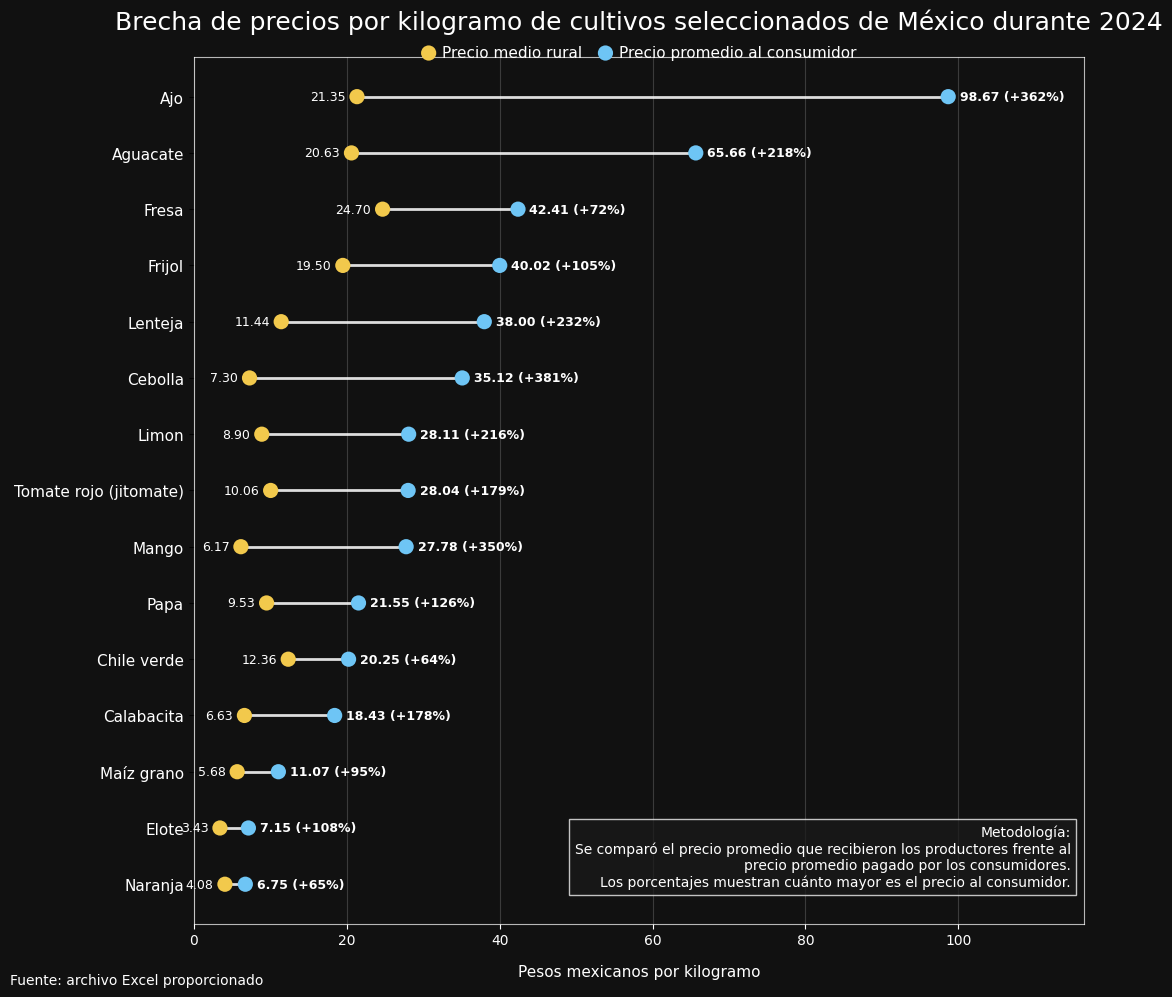

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def crear_grafica_brecha_precios(
    archivo_excel,
    hoja=0,
    salida_png="brecha_precios.png",
    titulo="Brecha de precios por kilogramo de cultivos seleccionados de México durante 2024"
):
    """
    Lee un archivo Excel con:
      Columna A: cultivo
      Columna B: precio medio rural
      Columna C: precio promedio consumidor

    y genera una gráfica tipo dumbbell.
    """

    # Leer archivo
    df = pd.read_excel(archivo_excel, sheet_name=hoja)

    # Renombrar columnas por posición para evitar depender de encabezados exactos
    df = df.iloc[:, :3].copy()
    df.columns = ["Cultivo", "Precio_Rural", "Precio_Consumidor"]

    # Limpiar filas vacías
    df = df.dropna(subset=["Cultivo", "Precio_Rural", "Precio_Consumidor"])

    # Convertir a numérico por seguridad
    df["Precio_Rural"] = pd.to_numeric(df["Precio_Rural"], errors="coerce")
    df["Precio_Consumidor"] = pd.to_numeric(df["Precio_Consumidor"], errors="coerce")
    df = df.dropna(subset=["Precio_Rural", "Precio_Consumidor"])

    # Calcular brecha porcentual
    df["Brecha_Pct"] = ((df["Precio_Consumidor"] - df["Precio_Rural"]) / df["Precio_Rural"]) * 100

    # Ordenar por precio consumidor descendente para parecerse al ejemplo
    df = df.sort_values("Precio_Consumidor", ascending=False).reset_index(drop=True)

    # Posiciones Y
    y = np.arange(len(df))

    # Figura
    fig, ax = plt.subplots(figsize=(11, max(10, len(df) * 0.35)), facecolor="#111111")
    ax.set_facecolor("#111111")

    # Líneas horizontales entre puntos
    for i, row in df.iterrows():
        ax.plot(
            [row["Precio_Rural"], row["Precio_Consumidor"]],
            [i, i],
            color="#DDDDDD",
            linewidth=2,
            zorder=1
        )

    # Puntos
    ax.scatter(
        df["Precio_Rural"], y,
        s=120, color="#f2c94c", edgecolors="none",
        label="Precio medio rural", zorder=3
    )
    ax.scatter(
        df["Precio_Consumidor"], y,
        s=120, color="#6ec5f5", edgecolors="none",
        label="Precio promedio al consumidor", zorder=3
    )

    # Etiquetas de valores
    for i, row in df.iterrows():
        # Rural
        ax.text(
            row["Precio_Rural"] - 1.5, i,
            f'{row["Precio_Rural"]:.2f}',
            va="center", ha="right",
            color="white", fontsize=9
        )

        # Consumidor + porcentaje
        ax.text(
            row["Precio_Consumidor"] + 1.5, i,
            f'{row["Precio_Consumidor"]:.2f} (+{row["Brecha_Pct"]:.0f}%)',
            va="center", ha="left",
            color="white", fontsize=9, fontweight="bold"
        )

    # Eje Y
    ax.set_yticks(y)
    ax.set_yticklabels(df["Cultivo"], fontsize=11, color="white")
    ax.invert_yaxis()

    # Eje X
    xmax = df["Precio_Consumidor"].max()
    ax.set_xlim(0, xmax * 1.18)
    ax.tick_params(axis="x", colors="white", labelsize=10)
    ax.set_xlabel("Pesos mexicanos por kilogramo", color="white", fontsize=11, labelpad=12)

    # Grid
    ax.grid(axis="x", color="white", alpha=0.18, linewidth=0.8)
    ax.grid(axis="y", visible=False)

    # Spines
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.7)

    # Título
    ax.set_title(
        titulo,
        color="white",
        fontsize=18,
        pad=20
    )

    # Leyenda
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=2,
        frameon=False,
        fontsize=11,
        handlelength=1.0,
        handletextpad=0.4,
        columnspacing=1.0
    )
    for text in legend.get_texts():
        text.set_color("white")

    # Caja de metodología
    metodologia = (
        "Metodología:\n"
        "Se comparó el precio promedio que recibieron los productores frente al\n"
        "precio promedio pagado por los consumidores.\n"
        "Los porcentajes muestran cuánto mayor es el precio al consumidor."
    )

    ax.text(
        0.985, 0.04, metodologia,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="white",
        bbox=dict(facecolor="#1a1a1a", edgecolor="white", alpha=0.75)
    )

    # Fuente
    fig.text(
        0.01, 0.01,
        "Fuente: archivo Excel proporcionado",
        color="white", fontsize=10
    )

    plt.tight_layout()
    plt.savefig(salida_png, dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()

"""
if __name__ == "__main__":
    crear_grafica_brecha_precios(
        archivo_excel="datos_cultivos.xlsx",
        hoja=0,
        salida_png="brecha_precios.png"
    )
"""

crear_grafica_brecha_precios(
    archivo_excel="Book1.xlsx",
    hoja=0,
    salida_png="brecha_precios.png")

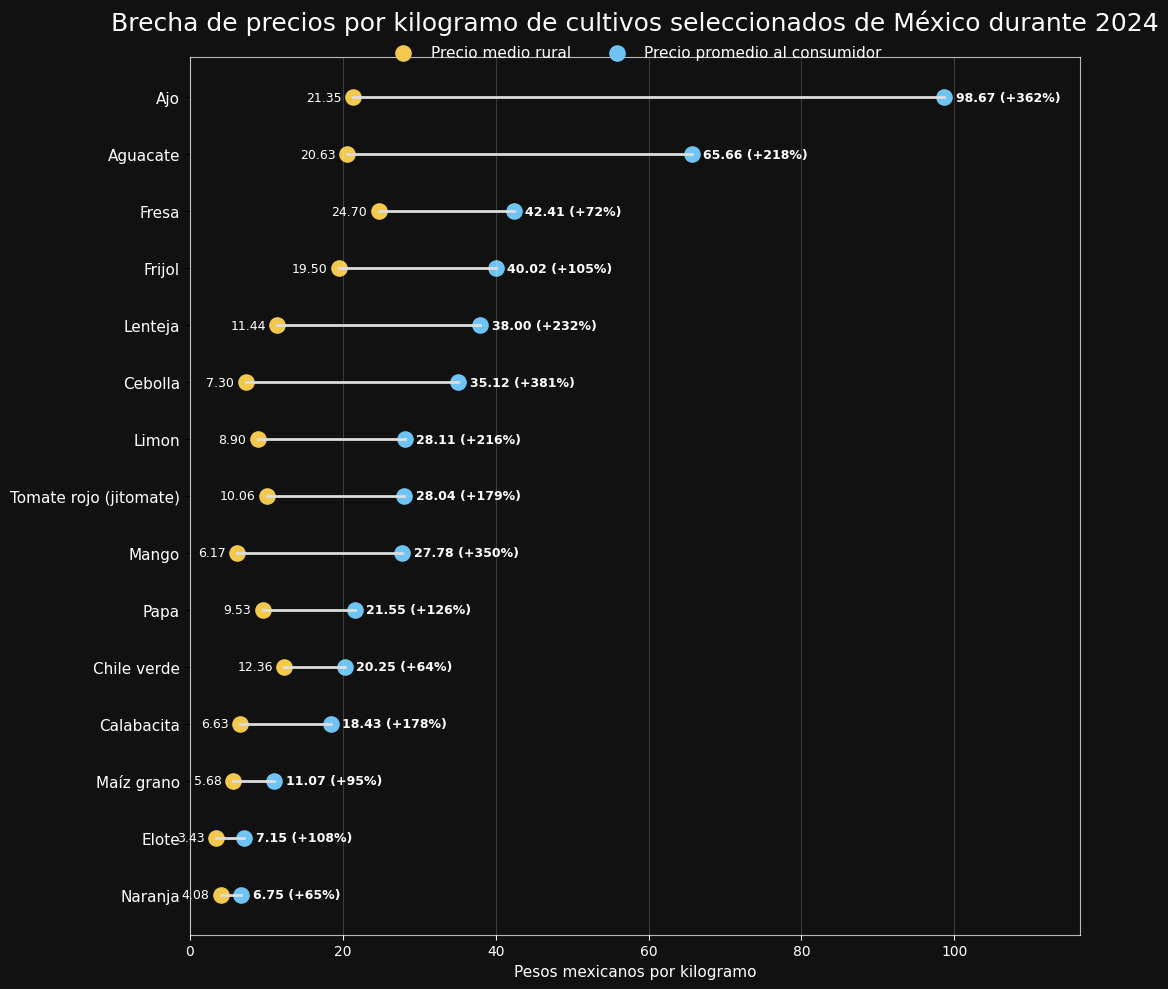

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def crear_grafica_brecha_precios(
    archivo_excel,
    hoja=0,
    salida_png="brecha_precios.png",
    titulo="Brecha de precios por kilogramo de cultivos seleccionados de México durante 2024"
):

    # Leer archivo
    df = pd.read_excel(archivo_excel, sheet_name=hoja)

    # Usar solo las primeras 3 columnas
    df = df.iloc[:, :3].copy()
    df.columns = ["Cultivo", "Precio_Rural", "Precio_Consumidor"]

    # Limpiar datos
    df = df.dropna(subset=["Cultivo", "Precio_Rural", "Precio_Consumidor"])
    df["Precio_Rural"] = pd.to_numeric(df["Precio_Rural"], errors="coerce")
    df["Precio_Consumidor"] = pd.to_numeric(df["Precio_Consumidor"], errors="coerce")
    df = df.dropna()

    # Calcular brecha porcentual
    df["Brecha_Pct"] = ((df["Precio_Consumidor"] - df["Precio_Rural"]) / df["Precio_Rural"]) * 100

    # Ordenar
    df = df.sort_values("Precio_Consumidor", ascending=False).reset_index(drop=True)

    # Posiciones eje Y
    y = np.arange(len(df))

    # Figura
    fig, ax = plt.subplots(figsize=(11, max(10, len(df) * 0.35)), facecolor="#111111")
    ax.set_facecolor("#111111")

    # Líneas entre puntos
    for i, row in df.iterrows():
        ax.plot(
            [row["Precio_Rural"], row["Precio_Consumidor"]],
            [i, i],
            color="#DDDDDD",
            linewidth=2
        )

    # Puntos
    ax.scatter(
        df["Precio_Rural"], y,
        s=120, color="#f2c94c",
        label="Precio medio rural"
    )

    ax.scatter(
        df["Precio_Consumidor"], y,
        s=120, color="#6ec5f5",
        label="Precio promedio al consumidor"
    )

    # Etiquetas
    for i, row in df.iterrows():

        ax.text(
            row["Precio_Rural"] - 1.5, i,
            f'{row["Precio_Rural"]:.2f}',
            va="center", ha="right",
            color="white", fontsize=9
        )

        ax.text(
            row["Precio_Consumidor"] + 1.5, i,
            f'{row["Precio_Consumidor"]:.2f} (+{row["Brecha_Pct"]:.0f}%)',
            va="center", ha="left",
            color="white", fontsize=9, fontweight="bold"
        )

    # Eje Y
    ax.set_yticks(y)
    ax.set_yticklabels(df["Cultivo"], fontsize=11, color="white")
    ax.invert_yaxis()

    # Eje X
    xmax = df["Precio_Consumidor"].max()
    ax.set_xlim(0, xmax * 1.18)
    ax.tick_params(axis="x", colors="white", labelsize=10)
    ax.set_xlabel("Pesos mexicanos por kilogramo", color="white", fontsize=11)

    # Grid
    ax.grid(axis="x", color="white", alpha=0.18)
    ax.grid(axis="y", visible=False)

    # Bordes
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.7)

    # Título
    ax.set_title(
        titulo,
        color="white",
        fontsize=18,
        pad=20
    )

    # Leyenda
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=2,
        frameon=False,
        fontsize=11
    )

    for text in legend.get_texts():
        text.set_color("white")

    plt.tight_layout()
    plt.savefig(salida_png, dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    crear_grafica_brecha_precios(
        archivo_excel="Book1.xlsx"
    )